In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

print("All libraries loaded!")

All libraries loaded!


In [2]:
# Load Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print(df.shape)
print(df.head())
print(df.describe())
print(df['species'].value_counts())

(150, 6)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%   

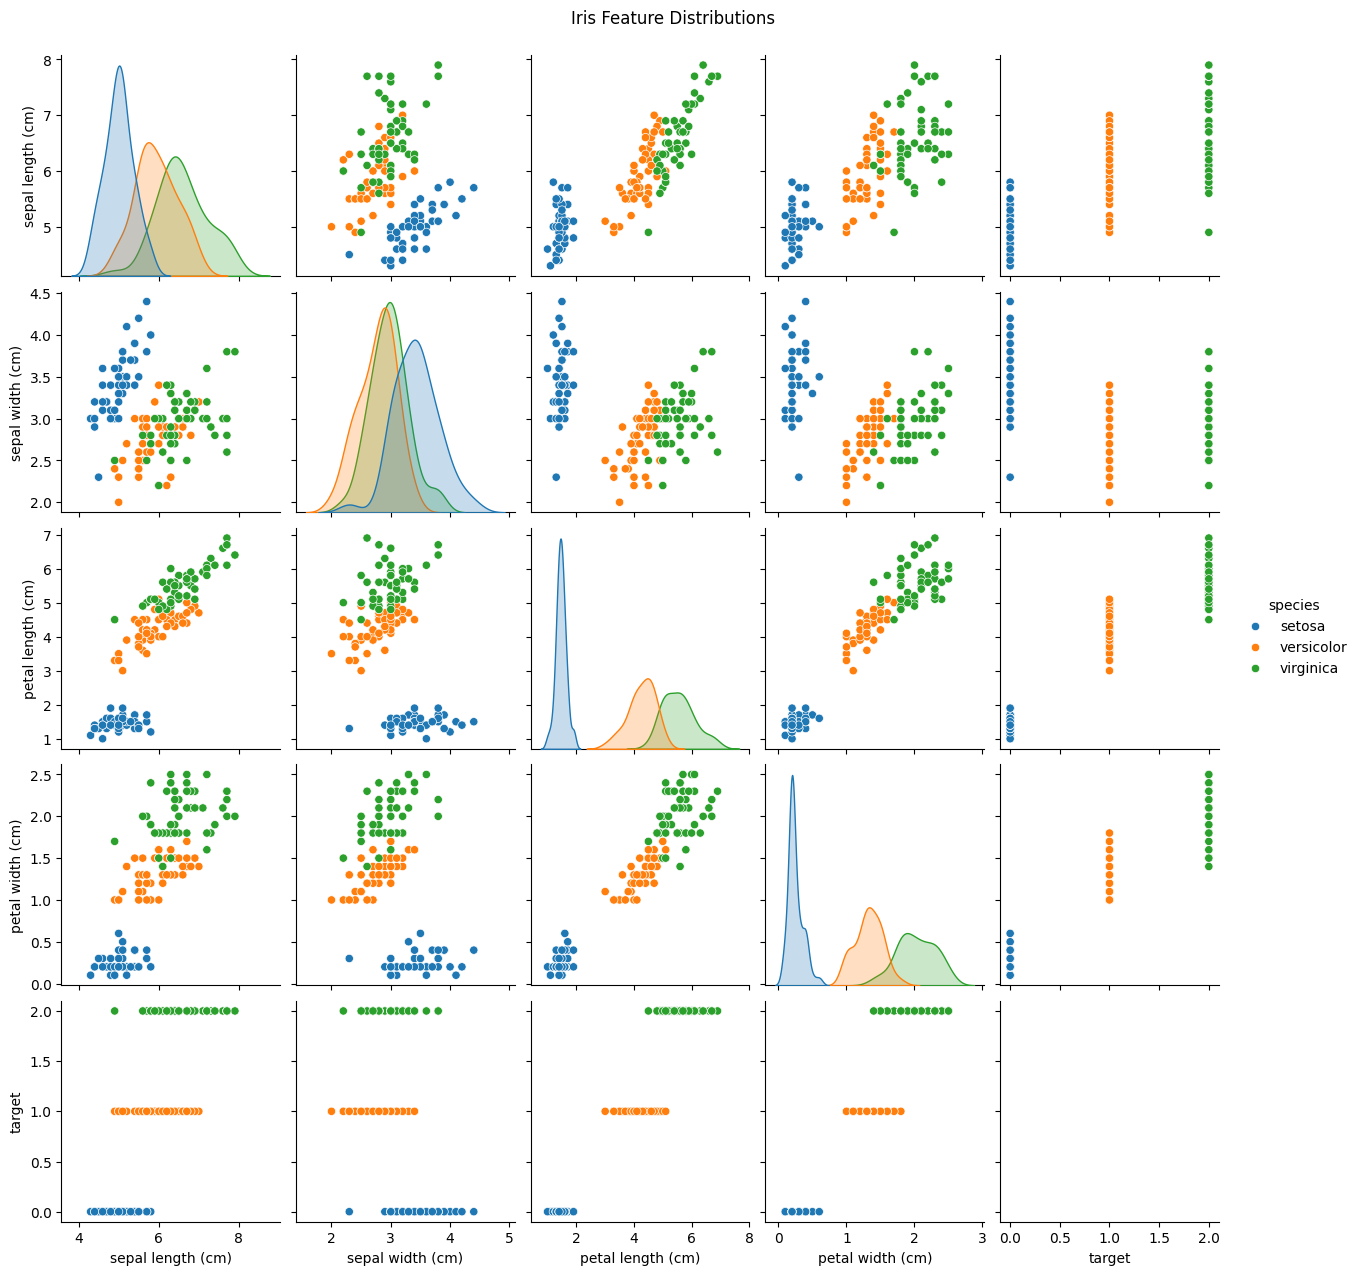

In [3]:
# Pairplot to visualize feature distributions
sns.pairplot(df, hue='species')
plt.suptitle('Iris Feature Distributions', y=1.02)
plt.show()

In [4]:
# Define features and target
X = df[iris.feature_names]
y = df['target']

# Split data 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (120, 4)
Testing set size: (30, 4)


k=1: accuracy=0.942
k=3: accuracy=0.950
k=5: accuracy=0.925
k=7: accuracy=0.942
k=9: accuracy=0.942
k=11: accuracy=0.950


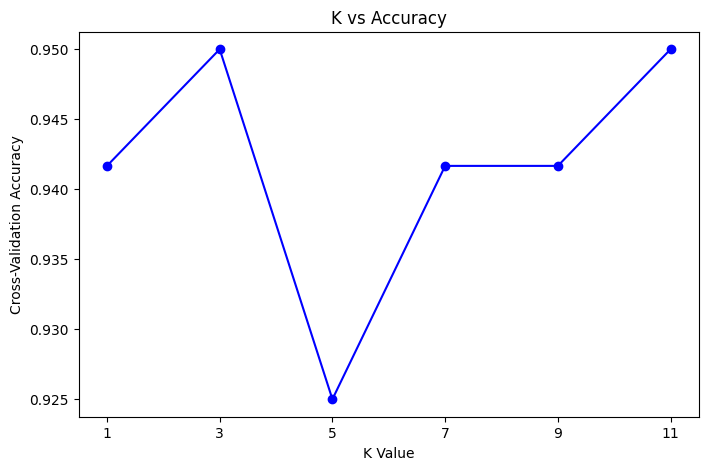


Best k: 3


In [5]:
# Test different k values
k_values = [1, 3, 5, 7, 9, 11]
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
    cv_scores.append(scores.mean())
    print(f"k={k}: accuracy={scores.mean():.3f}")

# Plot k vs accuracy
plt.figure(figsize=(8, 5))
plt.plot(k_values, cv_scores, marker='o', color='blue')
plt.title('K vs Accuracy')
plt.xlabel('K Value')
plt.ylabel('Cross-Validation Accuracy')
plt.xticks(k_values)
plt.show()

best_k = k_values[cv_scores.index(max(cv_scores))]
print(f"\nBest k: {best_k}")

In [6]:
# Train final model with best k
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

# Make predictions
y_pred = knn.predict(X_test_scaled)

# Evaluation metrics
print("Accuracy: ", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred, average='weighted'), 3))
print("Recall:   ", round(recall_score(y_test, y_pred, average='weighted'), 3))
print("F1-Score: ", round(f1_score(y_test, y_pred, average='weighted'), 3))
print()
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy:  1.0
Precision: 1.0
Recall:    1.0
F1-Score:  1.0

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



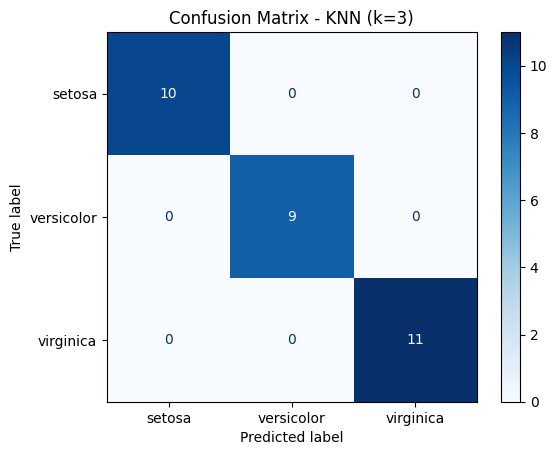

In [7]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - KNN (k=3)')
plt.show()

In [8]:
# Test on new sample data points
new_samples = pd.DataFrame([
    [5.1, 3.5, 1.4, 0.2],
    [6.2, 2.9, 4.3, 1.3],
    [7.3, 3.0, 6.3, 1.8]
], columns=iris.feature_names)

# Scale new samples
new_samples_scaled = scaler.transform(new_samples)

# Predict
predictions = knn.predict(new_samples_scaled)
species_names = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}

print("New Sample Predictions:")
for i, pred in enumerate(predictions):
    print(f"Sample {i+1}: {species_names[pred]}")

New Sample Predictions:
Sample 1: setosa
Sample 2: versicolor
Sample 3: virginica


In [9]:
print("=" * 55)
print("KNN CLASSIFICATION - KEY FINDINGS")
print("=" * 55)
print()
print("DATASET: Iris (150 samples, 4 features, 3 classes)")
print()
print("OPTIMAL K VALUE: 3")
print("Found using 5-fold cross-validation")
print()
print("MODEL PERFORMANCE (k=3):")
print("Accuracy:  100%")
print("Precision: 100%")
print("Recall:    100%")
print("F1-Score:  100%")
print()
print("CONFUSION MATRIX:")
print("All 30 test samples correctly classified")
print("0 misclassifications across all 3 species")
print()
print("NEW SAMPLE PREDICTIONS:")
print("Sample 1 [5.1,3.5,1.4,0.2] -> setosa")
print("Sample 2 [6.2,2.9,4.3,1.3] -> versicolor")
print("Sample 3 [7.3,3.0,6.3,1.8] -> virginica")
print()
print("KEY INSIGHTS:")
print("1. Feature scaling is critical for KNN performance")
print("2. k=3 gives optimal balance of bias and variance")
print("3. Petal length and width are strongest predictors")
print("=" * 55)

KNN CLASSIFICATION - KEY FINDINGS

DATASET: Iris (150 samples, 4 features, 3 classes)

OPTIMAL K VALUE: 3
Found using 5-fold cross-validation

MODEL PERFORMANCE (k=3):
Accuracy:  100%
Precision: 100%
Recall:    100%
F1-Score:  100%

CONFUSION MATRIX:
All 30 test samples correctly classified
0 misclassifications across all 3 species

NEW SAMPLE PREDICTIONS:
Sample 1 [5.1,3.5,1.4,0.2] -> setosa
Sample 2 [6.2,2.9,4.3,1.3] -> versicolor
Sample 3 [7.3,3.0,6.3,1.8] -> virginica

KEY INSIGHTS:
1. Feature scaling is critical for KNN performance
2. k=3 gives optimal balance of bias and variance
3. Petal length and width are strongest predictors
